In [4]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv(r"C:\Users\utkar\OneDrive\Desktop\aircraft-freights.csv") #loading file

In [6]:
df.head()

,id,date,state_name,state_code,airport,freight
0,0,2022-01-01,West Bengal,19,Kolkata,3088.0
1,1,2022-01-01,Tamil Nadu,33,Chennai,20054.0
2,2,2022-01-01,Goa,30,Goa,93.0
3,3,2022-01-01,Jammu and Kashmir,1,Srinagar,0.0
4,4,2022-01-01,Odisha,21,Bhubaneswar,0.0


In [7]:
df.isnull().sum()

id            0
date          0
state_name    0
state_code    0
airport       0
freight       0
dtype: int64

In [89]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df = df.groupby('date').agg({'freight': 'sum'}).reset_index()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

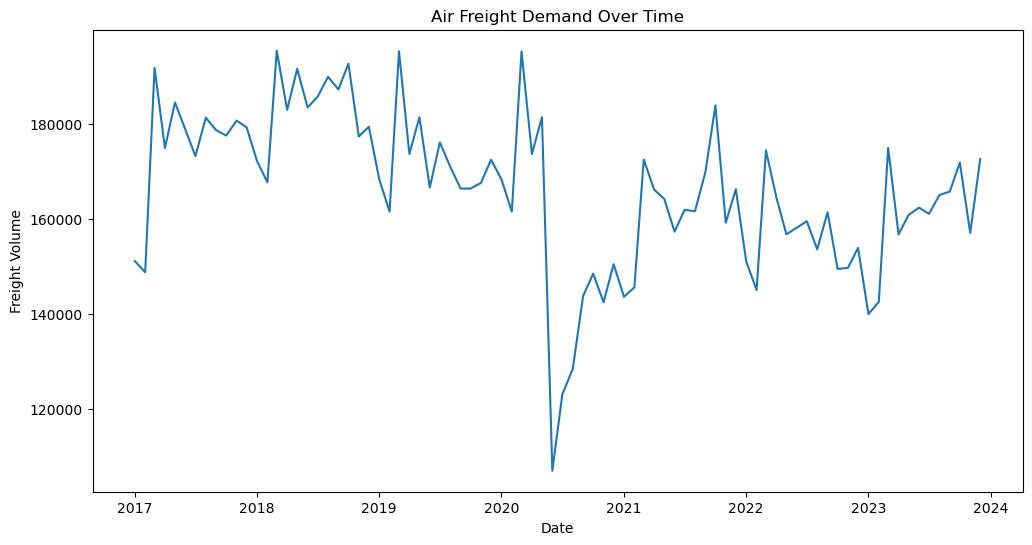

In [11]:
# Plot freight demand over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='freight')
plt.title('Air Freight Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Freight Volume')
plt.show()

In [12]:
# Feature Engineering
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['lag_1'] = df['freight'].shift(1)
df['rolling_mean_3'] = df['freight'].rolling(window=3).mean()
df.dropna(inplace=True)


In [13]:
# Define features and target
X = df[['year', 'month', 'day_of_week', 'lag_1', 'rolling_mean_3']]
y = df['freight']

In [14]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
# Scale target variable
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

In [77]:
# Build the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

D:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

In [81]:
# Train the model
model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=16, verbose=1)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7022  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6500 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6744 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4820 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4719 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5820 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3964 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4008 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3476 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3115 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3099 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2858 
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3778 
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2558 
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3613 
Epoch 16/100
5/5 ━

In [83]:
# Predict and inverse transform
y_pred_scaled = model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


In [85]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"ANN Performance:\nMAE: {mae}\nRMSE: {rmse}")


ANN Performance:
MAE: 6510.723345588235
RMSE: 9541.019818321976


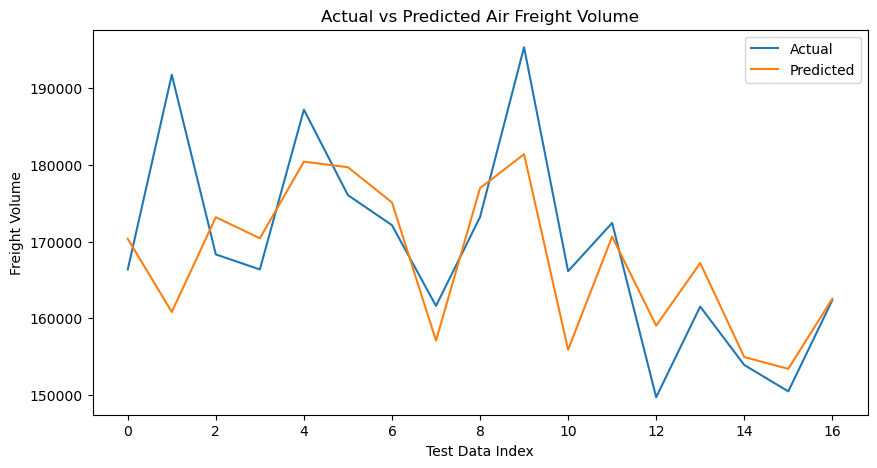

In [87]:
# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred.flatten(), label='Predicted')
plt.title('Actual vs Predicted Air Freight Volume')
plt.xlabel('Test Data Index')
plt.ylabel('Freight Volume')
plt.legend()
plt.show()


In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    }

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name} Performance:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}\n")

Linear Regression Performance:
MAE: 5073.182243040357
RMSE: 7181.158698262285

Random Forest Performance:
MAE: 7185.1647058823555
RMSE: 9965.310855460204

XGBoost Performance:
MAE: 5919.75919117647
RMSE: 11432.492970373329

